In [29]:
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask


print(f"[Line {inspect.currentframe().f_lineno}] ...  Done with cell. ")

[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

In [46]:
import pandas as pd
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

from IPython.display import display, HTML
display(HTML("<style>.jp-OutputArea {max-height: 200px}</style>"))


rows = []  # collect per-date stats here
#good dates in veracruz are 2024-01-13, 2025-01-12
startDate = "2025-03-21"
#startDate = "2022-05-18"
startDate = "2025-04-20"

#startDate = "2025-01-12"

#endDate = "2025-05-06"
endDate = "2025-06-20"

#endDate = "2022-12-31"


#endDate = "2022-12-31" # temporarily


# Villanueva, VER
#startDate = "2025-01-12"
#endDate = "2025-08-16"
#ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"
#bogus
#startDate = "2021-10-01"
#endDate = "2021-10-01"

dates = Utils.generate_date_range(startDate, endDate,  "%Y-%m-%d", 1)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
print ("*****  Constants.lat0, Constants.lon0 : ",Constants.lat0, Constants.lon0)
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

precip_df.head()
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
                                 
#dates = Utils.generate_date_range("2025-06-16", "2025-06-17",  "%Y-%m-%d", 5)

# jan 12, no cloud directly over farm.
#Feb 11, lots of clouds over farm
ndmi_tile_tif=""
print(f"Cell [Line {inspect.currentframe().f_lineno}] ... dates = ",dates)
        
for date in dates:
    
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date = ",date)
    gndvi_tile_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "gndvi","tif")
    ndmi_tile_tif  = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi", "tif")
    rgb_tile_tif   = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb.uint8","tif")

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ndmi_tile_tif = ",ndmi_tile_tif)
    gdf_box = ConstantObjects.gdf_box_terreno_casa
    ndmi_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi-terreno-casa","tif")
    ndmi_plots_2_3_1A_1B_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "plots_2_3_1A_1B","tif")
    ndmi_casa_y_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "casa_y_vecino","tif")
    #ndmi_milpa_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "milpa_vecino","tif")

    b02_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B02","jp2")
    b03_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B03","jp2")
    b04_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B04","jp2")
    if os.path.exists(b02_terreno_casa_jp2) and os.path.exists(b03_terreno_casa_jp2) and os.path.exists(b04_terreno_casa_jp2):
        print(f"[Line {inspect.currentframe().f_lineno}] ... found all three of B02,B03, and B04 .jp2 images. Moving forward. ")
    else:
        print(f"[Line {inspect.currentframe().f_lineno}] ... will have to try the next date, because unable to find files:  ", b02_terreno_casa_jp2 ," , " , b03_terreno_casa_jp2," , " , b04_terreno_casa_jp2  )
        continue #If we do not have all three files for this date we should move on to the next date.
    green_vs_red_blue = np.nan
    rgb_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb-terreno-casa","tif")

    print(f"[Line {inspect.currentframe().f_lineno}] ... ndmi_terreno_casa_tif = ",ndmi_terreno_casa_tif)

    
    #cloud_terreno_casa = Utils.estimate_cloud_fraction_rgb_over_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa,treat_zero_as_nodata=True)
    # add up red intensity
    b2_intensity_terreno_casa = Utils.crop_and_sum_intensity(b02_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b3_intensity_terreno_casa = Utils.crop_and_sum_intensity(b03_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b4_intensity_terreno_casa = Utils.crop_and_sum_intensity(b04_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b2_norm_reflectance_terreno_casa = b2_intensity_terreno_casa["sum"]/b2_intensity_terreno_casa["valid_pixels"]
    b3_norm_reflectance_terreno_casa = b3_intensity_terreno_casa["sum"]/b3_intensity_terreno_casa["valid_pixels"]
    b4_norm_reflectance_terreno_casa = b4_intensity_terreno_casa["sum"]/b4_intensity_terreno_casa["valid_pixels"]
    red_green_blue_average = (b2_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa)/3 
    #SCF continue here..
    cloudy =0
    if (red_green_blue_average) > 1650:  cloudy = 1

    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_terreno_casa, ndmi_terreno_casa_tif) ")
    stats_terreno_casa = {
        "count_valid": 0,
        "mean": float("nan"),
        "median": float("nan"),
    }
    stats_casa_y_vecino = stats_terreno_casa

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")
    if not cloudy: stats_casa_y_vecino  = Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_casa_y_vecino , ndmi_casa_y_vecino_tif)  

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    print("Avg NDMI over AOI plots 4,5:", stats_casa_y_vecino["mean"])
  
    print(f"[Line {inspect.currentframe().f_lineno}] ...  ")
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    ndmi_plots_4_5_stats       =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      ndmi_tile_tif, "ndmi_plots_4_5",       date, cloudy)
    ndmi_plots_2_3_1A_1B_stats =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,ndmi_tile_tif, "ndmi_plots_2_3_1A_1B", date, cloudy)
    ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
    #ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
    ndmi_milpa_vecino_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,   ndmi_tile_tif, "ndmi_milpa_vecino",    date, cloudy)
    ndmi_terreno_casa_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_terreno_casa,   ndmi_tile_tif, "ndmi_terreno_casa",    date, cloudy)
    gndvi_plots_4_5_stats      =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      gndvi_tile_tif,"gndvi_plots_4_5",      date, cloudy)
    gndvi_plots_2_3_1A_1B_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,gndvi_tile_tif,"gndvi_plots_2_3_1A_1B",date, cloudy)
    #gndvi_milpa1_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa1,gndvi_tile_tif,"gndvi_milpa1",date, cloudy)
    gndvi_milpa1_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,gndvi_tile_tif,"gndvi_milpa1",date, cloudy)

    gndvi_milpa_vecino_stats   =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,gndvi_tile_tif,"gndvi_milpa_vecino",date, cloudy)

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_4_5_stats.get(mean,   np.nan) = ",gndvi_plots_4_5_stats.get("mean",   np.nan))
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_2_3_1A_1B_stats.get(mean,   np.nan) = ",gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan))

    #gndvi_reference = gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan)
    #ndmi_reference  = ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan)
    gndvi_reference = gndvi_milpa_vecino_stats.get("mean",   np.nan)
    ndmi_reference  = ndmi_milpa_vecino_stats.get("mean",   np.nan)
    
    rows.append({
        "date": date,
        "ndmi_terreno_casa":      ndmi_terreno_casa_stats.get("mean", np.nan),
        # Now making measurements relative to milpa_vecino
        "gndvi_plots_4_5":        gndvi_plots_4_5_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_plots_2_3_1A_1B":  gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_milpa1":           gndvi_milpa1_stats.get("mean",   np.nan)-gndvi_reference,

        "gndvi_milpa_vecino":     gndvi_milpa_vecino_stats.get("mean",   np.nan)-gndvi_reference,
        
        "ndmi_plots_4_5":         ndmi_plots_4_5_stats.get ("mean",   np.nan)-ndmi_reference,
        "ndmi_plots_2_3_1A_1B":   ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-ndmi_reference,
        "ndmi_milpa1":            ndmi_milpa1_stats.get("mean",   np.nan)-ndmi_reference,

        "ndmi_milpa_vecino":      ndmi_milpa_vecino_stats.get("mean",   np.nan)-ndmi_reference,
        
        "red": b2_norm_reflectance_terreno_casa,
        "green": b3_norm_reflectance_terreno_casa,
        "blue": b4_norm_reflectance_terreno_casa,
        "red_green_blue_average": red_green_blue_average,
        "cloudy" : cloudy *1

    })    
    print(f"[Line {inspect.currentframe().f_lineno}] ... Just appended to rows, an entry with date = ",date)
    print(f"[Cell Line {inspect.currentframe().f_lineno}] ... b2_intensity_terreno_casa[sum]  ",b2_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b3_intensity_terreno_casa[sum]  ",b3_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b4_intensity_terreno_casa[sum]  ",b4_intensity_terreno_casa["sum"])
    #print(f"Cell [Line {inspect.currentframe().f_lineno}] ... stats_milpa_vecino.get(mean,   np.nan)  ",stats_milpa_vecino.get("mean",   np.nan))

    #Utils.show_ndmi_moist(ndmi_terreno_casa_tif, scale=12)
    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa, rgb_terreno_casa_tif)  ")
 
    #Utils.show_tif_fit(rgb_terreno_casa_tif, scale=12, cmap="gray")
    print(f"[Line {inspect.currentframe().f_lineno}] ... ")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")

[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

[Line 47] ...   
*****  Constants.lat0, Constants.lon0 :  19.7782 -96.86942
[Line 1301] ...   
[Line 1306] ...   
[Line 1309] ... pd.to_datetime(d[time])   DatetimeIndex(['2025-04-20', '2025-04-21', '2025-04-22', '2025-04-23',
               '2025-04-24', '2025-04-25', '2025-04-26', '2025-04-27',
               '2025-04-28', '2025-04-29', '2025-04-30', '2025-05-01',
               '2025-05-02', '2025-05-03', '2025-05-04', '2025-05-05',
               '2025-05-06', '2025-05-07', '2025-05-08', '2025-05-09',
               '2025-05-10', '2025-05-11', '2025-05-12', '2025-05-13',
               '2025-05-14', '2025-05-15', '2025-05-16', '2025-05-17',
               '2025-05-18', '2025-05-19', '2025-05-20', '2025-05-21',
               '2025-05-22', '2025-05-23', '2025-05-24', '2025-05-25',
               '2025-05-26', '2025-05-27', '2025-05-28', '2025-05-29',
               '2025-05-30', '2025-05-31', '2025-06-01', '2025-06-02',
               '2025-06-03', '2025-06-04', '2025-06-05', '2025-

In [47]:
# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)    

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df["date"] = pd.to_datetime(df["date"]).dt.normalize()

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)


df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#df = pd.DataFrame(rows)
print(df.columns.tolist())
print(df.head())
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#Borana University, Ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"

def to_mx_date(col):
    return pd.to_datetime(col, utc=True).dt.tz_convert("America/Mexico_City").dt.normalize()

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# --- existing: daily precip
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
p = precip_df.copy()
p["date"] = p["date"].dt.tz_localize(None)
#p["date"] = pd.to_datetime(p["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

temp_df = Utils.daily_temp_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
t = temp_df.copy()
t["date"] = pd.to_datetime(t["date"]).dt.tz_localize(None)
#t["date"] = pd.to_datetime(t["date"]).dt.normalize()
p = p.merge(t, on="date", how="left").sort_values("date")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#p = p.sort_values("date")

# align daily precip with sparse NDMI, for excel:
out = p.merge(df, on="date", how="left")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# save for Excel
out.to_csv("daily_table.csv", index=False)
# or
# out.to_excel("daily_table.xlsx", index=False)
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")


[Cell Line 4] .. df =            date  ndmi_terreno_casa  gndvi_plots_4_5  gndvi_plots_2_3_1A_1B  \
0   2025-04-22                NaN              NaN                    NaN   
1   2025-04-27           0.174234        -0.044035               0.028392   
2   2025-05-02           0.125024              NaN                    NaN   
3   2025-05-07           0.143888        -0.068115               0.045470   
4   2025-05-12           0.166985        -0.082845               0.045250   
5   2025-05-17           0.143650        -0.041143               0.042886   
6   2025-05-22           0.157882        -0.021556               0.062137   
7   2025-05-27           0.197726         0.001563               0.065222   
8   2025-06-01                NaN              NaN                    NaN   
9   2025-06-06                NaN              NaN                    NaN   
10  2025-06-11           0.237011         0.010346               0.053496   
11  2025-06-16                NaN              NaN   

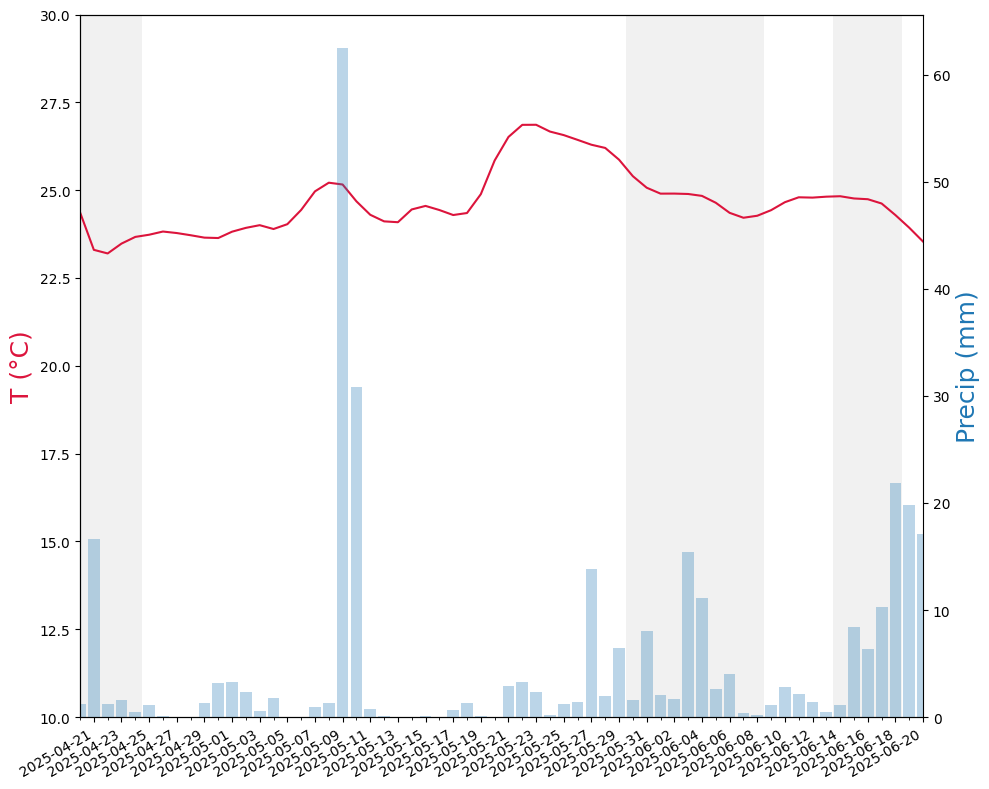

In [48]:
import MatPlotLibUtils
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#importlib.reload(MatPlotLibUtils)
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(matplotlib)

import pandas

warmDryStart2025 = pandas.to_datetime("2025-03-15")
warmDryEnd2025   = pandas.to_datetime("2025-05-18") 
display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, ax = plt.subplots(figsize=(10, 8))
#ax=axes


minTemp = 10
maxTemp = 30
myfontsize = 18
#ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax.bar(df["date"], df["cloudy"].fillna(0)*maxTemp,color="lightgrey",
        width=pd.Timedelta("5D"), alpha=0.3, label="Cloudy")
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
#ax.set_ylabel("NDMI")
#ax.legend(loc="upper center")
ax.set_frame_on(True); ax.patch.set_visible(False)

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
# Precip (second right axis; ALL daily bars)
ax2.bar(p["date"], p["precip_mm"].fillna(0),
        width=pd.Timedelta("0.85D"), alpha=0.3, label="Precip (mm)",color=precip_color)


#axes[2].set_ylabel("NDMI (Moisture)",fontsize = myfontsize)



# horizontal line
#start = pd.to_datetime("2024-03-01")
#end   = pd.to_datetime("2024-05-31")

# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
ax.set_xlim(xmin, xmax)


ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))   # tick every 5 days
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))



fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("temp_precipitation_plot.png", dpi=300, bbox_inches="tight")

In [49]:
importlib.reload(Utils)
# Variables
api_key = "E6RKNQ36BSLC8EUK5S3C5AKUQ"
location = "19.777411,-96.870102"  # Change location as needed
#start_date = startDate #"2025-03-21"
#end_date = "2025-05-06" # For article. Just to show context of visit.
end_date = endDate #"2025-06-30"
unit_group = "metric" 

# Fetch the weather data
weather_data = Utils.fetch_weather_data(api_key, location, startDate, endDate, unit_group)
date_array = [len(weather_data)] 
temp_array= [len(weather_data)]
precip_array= [len(weather_data)]
counter = 0
if weather_data:
    # Print sample data
    for day in weather_data['days']:
        print(f"Date: {day['datetime']}, Temperature: {day['temp']} °C, Precipitation: {day['precip']} mm")
        print("counter = ", counter)
        date_array[counter] = day['datetime']
        temp_array[counter] = day['temp']
        precip_array[counter] = day['precip']
        




Date: 2025-04-20, Temperature: 22.2 °C, Precipitation: 12.0 mm
counter =  0
Date: 2025-04-21, Temperature: 20.6 °C, Precipitation: 5.0 mm
counter =  0
Date: 2025-04-22, Temperature: 20.5 °C, Precipitation: 0.2 mm
counter =  0
Date: 2025-04-23, Temperature: 21.2 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-04-24, Temperature: 21.9 °C, Precipitation: 0.1 mm
counter =  0
Date: 2025-04-25, Temperature: 21.8 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-04-26, Temperature: 22.1 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-04-27, Temperature: 21.9 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-04-28, Temperature: 21.4 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-04-29, Temperature: 21.0 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-04-30, Temperature: 21.9 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-05-01, Temperature: 21.2 °C, Precipitation: 4.0 mm
counter =  0
Date: 2025-05-02, Temperature: 21.5 °C, Precipitation: 0.0 mm
counter =  0
Date: 2025-05-03, Temper

dates =  ['2025-04-20', '2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24', '2025-04-25', '2025-04-26', '2025-04-27', '2025-04-28', '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04', '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08', '2025-05-09', '2025-05-10', '2025-05-11', '2025-05-12', '2025-05-13', '2025-05-14', '2025-05-15', '2025-05-16', '2025-05-17', '2025-05-18', '2025-05-19', '2025-05-20', '2025-05-21', '2025-05-22', '2025-05-23', '2025-05-24', '2025-05-25', '2025-05-26', '2025-05-27', '2025-05-28', '2025-05-29', '2025-05-30', '2025-05-31', '2025-06-01', '2025-06-02', '2025-06-03', '2025-06-04', '2025-06-05', '2025-06-06', '2025-06-07', '2025-06-08', '2025-06-09', '2025-06-10', '2025-06-11', '2025-06-12', '2025-06-13', '2025-06-14', '2025-06-15', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-19', '2025-06-20']
precipitations =  [12.0, 5.0, 0.2, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 34.6, 0.7, 0.0, 0.1, 0.0, 0.0, 33.7, 

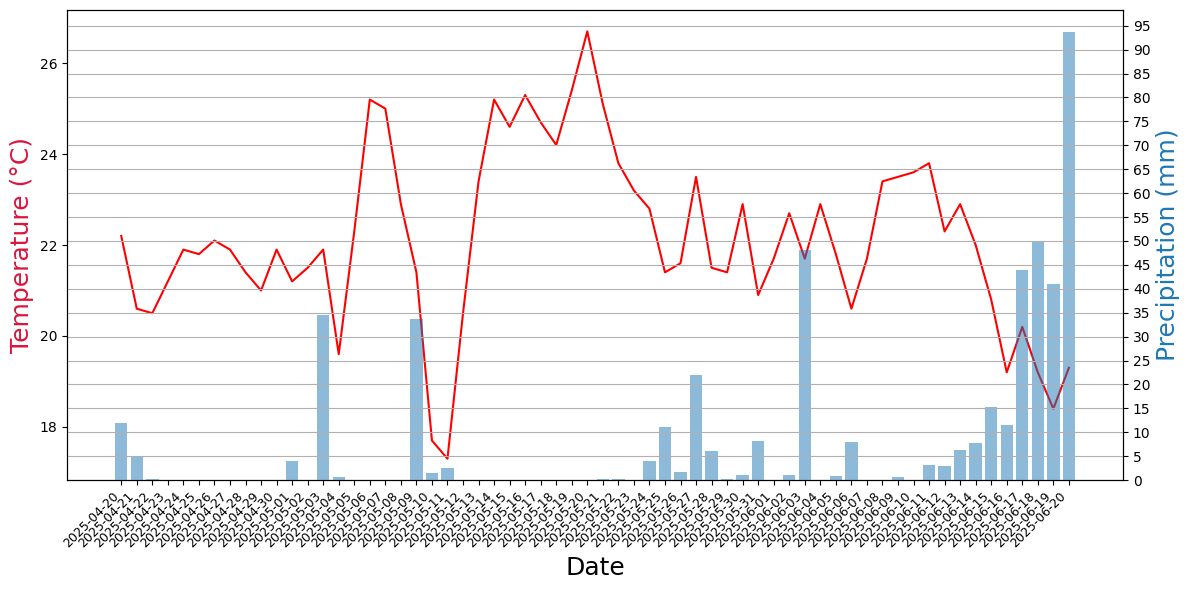

In [56]:

import matplotlib.pyplot as plt
import numpy as np
precip_color = "tab:blue"
temperature_color   = "crimson"
minTemp = 10
maxTemp = 30
myfontsize = 18
startDate = "2025-05-01"
# Plotting
if weather_data:
    dates = [day['datetime'] for day in weather_data['days']]
    temperatures = [day['temp'] for day in weather_data['days']]
    precipitations = [day['precip'] for day in weather_data['days']]
    print ("dates = ",dates)
    print ("precipitations = ",precipitations)
    #fig = plt.figure(figsize=(12, 6))

    fig, ax = plt.subplots(figsize=(12, 6))

    
    #host = fig.add_axes( axes_class=HostAxes)
    ax.plot(dates, temperatures,   color='r', marker='none', label='Temperature (°C)')
    
    plt.xlabel('Date',fontsize = myfontsize)
    plt.ylabel('Temperature (°C)', color = temperature_color,fontsize = myfontsize)
    
    #plt.title(f'Weather Data from {startDate} to {endDate} at {location}',fontsize = myfontsize)
    plt.xticks(rotation=45,ha = "right",fontsize=9)


    ax2 = ax.twinx()
    ax2.set_ylabel("Precipitation (mm)",color=precip_color,fontsize = myfontsize)
    #par1 = plt.get_aux_axes(viewlim_mode=None, sharex=host) # add a "parasitic" axis
    #ax2.ylabel('Precipitation', color = "blue")
    ax2.bar (dates, precipitations, color=precip_color, alpha=0.5, label='Precipitation (mm)')
    ax2.yaxis.set_ticks(np.arange(0, 100, 5))
    ax2.grid(visible=None, which='major', axis='both')
    
    #for tick in plt.xaxis.get_majorticklabels():
    #    tick.set_horizontalalignment("right")
    #plt.legend()
    plt.tight_layout()
    plt.show()  
    fig.savefig("temp_precipitation_only.png", dpi=300, bbox_inches="tight")